In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
BASE_PATH     = "/content/drive/MyDrive/FinalProject/new data"
METADATA_PATH = os.path.join(BASE_PATH, "HAM10000_metadata.csv")
IMAGES_PATH   = os.path.join(BASE_PATH, "images")
MODEL_DIR     = "/content/drive/MyDrive/FinalProject/models"
BEST_MODEL_V3 = os.path.join(MODEL_DIR, "best_model_v3.pth")

os.makedirs(MODEL_DIR, exist_ok=True)

In [13]:
df = pd.read_csv(METADATA_PATH)
df = df.dropna(subset=["image_id"]).reset_index(drop=True)

suspicious_map = {
    "mel": 1, "bcc": 1, "akiec": 1,
    "nv": 0,  "bkl": 0, "df": 0, "vasc": 0
}
df["suspicious"] = df["dx"].map(suspicious_map)

train_df = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/train_df.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/val_df.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/test_df.csv")

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 7010 | Val: 1502 | Test: 1503


In [14]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(300, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [15]:
class SkinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"] + ".jpg")
        try:
            img = Image.open(img_path).convert("RGB")
        except:
            img = Image.fromarray(np.zeros((300,300,3), dtype=np.uint8))
        label = torch.tensor(int(row["suspicious"]), dtype=torch.long)
        if self.transform:
            img = self.transform(img)
        return img, label, row["image_id"]

train_dataset = SkinDataset(train_df, IMAGES_PATH, train_transforms)
val_dataset   = SkinDataset(val_df,   IMAGES_PATH, val_transforms)
test_dataset  = SkinDataset(test_df,  IMAGES_PATH, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print("Loaders ready!")

Loaders ready!


In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = timm.create_model("efficientnet_b3", pretrained=True, num_classes=2).to(device)

# Weighted Loss
class_weights = torch.tensor([1.0, 3.0], device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)


Device: cuda


In [17]:
# ========================
# TRAINING LOOP - V3
# ========================

EPOCHS = 20

history_v3 = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss_v3 = float("inf")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    start_time = time.time()

    # TRAIN
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    pbar = tqdm(train_loader, desc="Training", leave=False)

    for images, labels, _ in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{train_correct/train_total:.4f}"
        })

    scheduler.step()

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels, _ in tqdm(val_loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_time = time.time() - start_time

    tl = train_loss / len(train_loader)
    vl = val_loss / len(val_loader)
    ta = train_correct / train_total
    va = val_correct / val_total

    history_v3["train_loss"].append(tl)
    history_v3["val_loss"].append(vl)
    history_v3["train_acc"].append(ta)
    history_v3["val_acc"].append(va)

    if vl < best_val_loss_v3:
        best_val_loss_v3 = vl
        torch.save(model.state_dict(), BEST_MODEL_V3)
        print("Saved best_model_v3.pth")

    print(f"Train Loss: {tl:.4f} | Train Acc: {ta:.4f}")
    print(f"Val   Loss: {vl:.4f} | Val   Acc: {va:.4f}")
    print(f"Time: {epoch_time:.2f}s | LR: {scheduler.get_last_lr()[0]:.6f}")
    print("-" * 50)


Epoch 1/20


Saved best_model_v3.pth
Train Loss: 0.7389 | Train Acc: 0.7813
Val   Loss: 0.5476 | Val   Acc: 0.7503
Time: 28.27s | LR: 0.000199
--------------------------------------------------

Epoch 2/20


Saved best_model_v3.pth
Train Loss: 0.3900 | Train Acc: 0.8294
Val   Loss: 0.3863 | Val   Acc: 0.8389
Time: 28.67s | LR: 0.000195
--------------------------------------------------

Epoch 3/20


Train Loss: 0.3218 | Train Acc: 0.8723
Val   Loss: 0.4273 | Val   Acc: 0.8748
Time: 28.30s | LR: 0.000189
--------------------------------------------------

Epoch 4/20


Saved best_model_v3.pth
Train Loss: 0.2505 | Train Acc: 0.8969
Val   Loss: 0.3552 | Val   Acc: 0.8895
Time: 27.55s | LR: 0.000181
--------------------------------------------------

Epoch 5/20


...

Train Loss: 0.0209 | Train Acc: 0.9936
Val   Loss: 0.5530 | Val   Acc: 0.9154
Time: 28.13s | LR: 0.000019
--------------------------------------------------

Epoch 17/20


Train Loss: 0.0199 | Train Acc: 0.9937
Val   Loss: 0.5486 | Val   Acc: 0.9181
Time: 28.45s | LR: 0.000011
--------------------------------------------------

Epoch 18/20


Train Loss: 0.0405 | Train Acc: 0.9956
Val   Loss: 0.6329 | Val   Acc: 0.9194
Time: 28.29s | LR: 0.000005
--------------------------------------------------

Epoch 19/20


Train Loss: 0.0283 | Train Acc: 0.9951
Val   Loss: 0.5938 | Val   Acc: 0.9121
Time: 28.21s | LR: 0.000001
--------------------------------------------------

Epoch 20/20


Train Loss: 0.0139 | Train Acc: 0.9960
Val   Loss: 0.5936 | Val   Acc: 0.9201
Time: 28.17s | LR: 0.000000
--------------------------------------------------


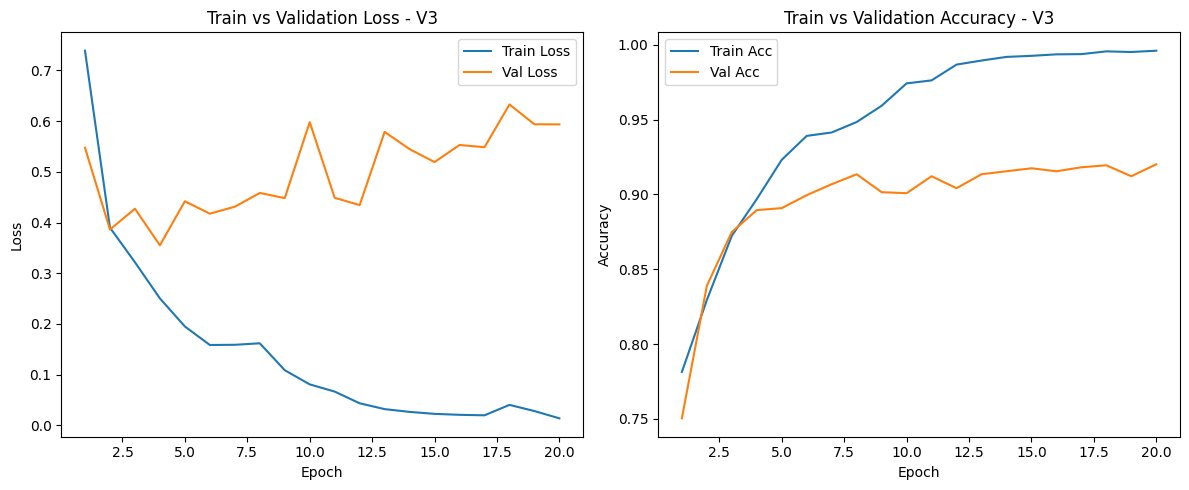

In [18]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, history_v3["train_loss"], label="Train Loss")
plt.plot(epochs, history_v3["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss - V3")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_v3["train_acc"], label="Train Acc")
plt.plot(epochs, history_v3["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy - V3")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
model.load_state_dict(torch.load(BEST_MODEL_V3, map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels, _ in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\nTest Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=["Not Suspicious", "Suspicious"]))


Test Accuracy: 0.8762
                precision    recall  f1-score   support

Not Suspicious       0.93      0.91      0.92      1210
    Suspicious       0.66      0.74      0.70       293

      accuracy                           0.88      1503
     macro avg       0.80      0.82      0.81      1503
  weighted avg       0.88      0.88      0.88      1503

